# SONAR Quick Start

This notebook demonstrates how to load the SONAR dataset, explore its properties,
run a graph anomaly detector, and evaluate the results.

## Installation

```bash
pip install sonar-graph
```

## 1. Load the SONAR Small Dataset

In [1]:
from sonar import SONAR, dataset_summary

# Load homogeneous graph with anomalies (auto-downloaded)
dataset = SONAR(root="./data", name="small", anomalies=True)
data = dataset[0]
print(dataset)
print(f"Nodes: {data.num_nodes}, Edges: {data.num_edges}")
print(f"Features: {data.x.shape[1]}, Anomalies: {int(data.y_outlier.sum())}")

SONAR(small, +anomalies, homogeneous)
Nodes: 36860, Edges: 49865
Features: 16, Anomalies: 1818


Processing...
Done!


In [2]:
# Load heterogeneous (clean) variant
dataset_hetero = SONAR(root="./data", name="small", anomalies=False,
                       representation="heterogeneous")
data_hetero = dataset_hetero[0]
print(dataset_hetero)
print(data_hetero)

SONAR(small, clean, heterogeneous)
HeteroData(
  user={ x=[18430, 4] },
  tweet={ x=[18429, 772] },
  hashtag={
    y=[1],
    train_mask=[1],
    test_mask=[1],
  },
  (user, post_original, tweet)={ edge_index=[2, 10671] },
  (user, post_quote, tweet)={ edge_index=[2, 4365] },
  (user, post_reply, tweet)={ edge_index=[2, 3394] },
  (tweet, quotes, tweet)={ edge_index=[2, 858] },
  (tweet, replies, tweet)={ edge_index=[2, 1519] },
  (tweet, mentions, user)={ edge_index=[2, 2348] },
  (tweet, hashtagedge, hashtag)={ edge_index=[2, 18430] }
)


Processing...
Done!


## 2. Dataset Summary

In [3]:
# Homogeneous summary
summary = dataset_summary(data)
for k, v in summary.items():
    print(f"{k}: {v}")

type: homogeneous
num_nodes: 36860
num_edges: 49865
num_features: 16
num_anomalies: 1818
anomaly_ratio: 0.0493


In [4]:
# Heterogeneous summary
summary_hetero = dataset_summary(data_hetero)
for k, v in summary_hetero.items():
    print(f"{k}: {v}")

type: heterogeneous
node_types: ['user', 'tweet', 'hashtag']
edge_types: ['(user, post_original, tweet)', '(user, post_quote, tweet)', '(user, post_reply, tweet)', '(tweet, quotes, tweet)', '(tweet, replies, tweet)', '(tweet, mentions, user)', '(tweet, hashtagedge, hashtag)']
num_nodes: {'user': 18430, 'tweet': 18429, 'hashtag': None}
num_edges: {'(user, post_original, tweet)': 10671, '(user, post_quote, tweet)': 4365, '(user, post_reply, tweet)': 3394, '(tweet, quotes, tweet)': 858, '(tweet, replies, tweet)': 1519, '(tweet, mentions, user)': 2348, '(tweet, hashtagedge, hashtag)': 18430}
num_features: {'user': 4, 'tweet': 772}


/home/h0p04i8/Development/sonar/sonar/utils.py:65: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'train_mask', 'test_mask', 'y'}'. Please explicitly set 'num_nodes' as an attribute of 'data[hashtag]' to suppress this warning
  summary["num_nodes"] = {nt: data[nt].num_nodes for nt in data.node_types}


## 3. Visualize Graph Properties

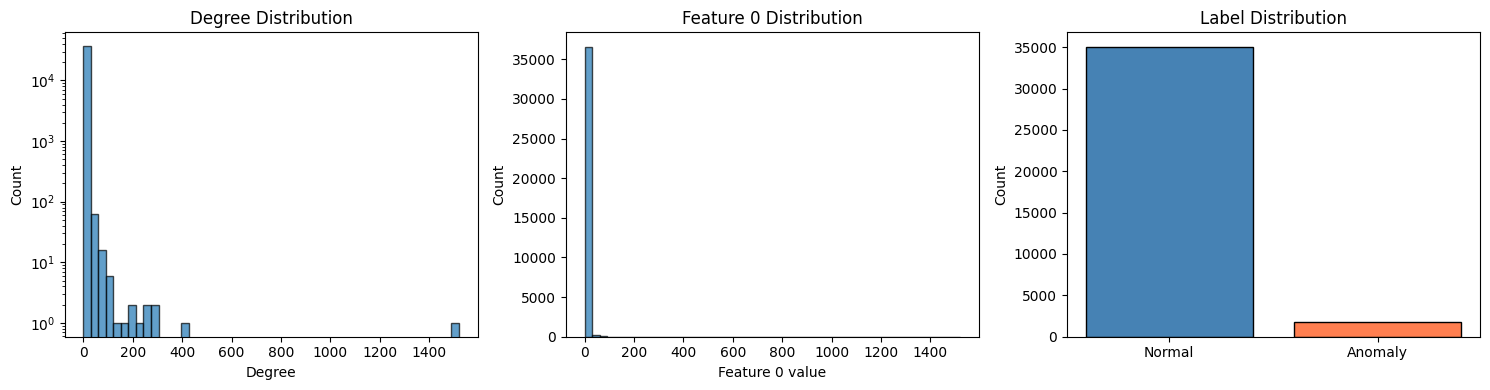

In [5]:
import matplotlib.pyplot as plt
import torch
from torch_geometric.utils import degree

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Degree distribution
deg = degree(data.edge_index[0], num_nodes=data.num_nodes)
axes[0].hist(deg.numpy(), bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Count")
axes[0].set_title("Degree Distribution")
axes[0].set_yscale("log")

# Feature distribution (first feature)
axes[1].hist(data.x[:, 0].numpy(), bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Feature 0 value")
axes[1].set_ylabel("Count")
axes[1].set_title("Feature 0 Distribution")

# Anomaly label distribution
labels, counts = torch.unique(data.y_outlier, return_counts=True)
axes[2].bar(["Normal", "Anomaly"], counts.numpy(), color=["steelblue", "coral"],
            edgecolor="black")
axes[2].set_ylabel("Count")
axes[2].set_title("Label Distribution")

plt.tight_layout()
plt.show()

## 4. Run a Detector (DOMINANT)

In [6]:
from pygod.detector import DOMINANT

detector = DOMINANT(epoch=5, gpu=-1, verbose=1)
detector.fit(data)
pred, score = detector.predict(data, return_pred=True, return_score=True)

print(f"Outliers detected: {int(pred.sum())}")
print(f"Score range: [{score.min():.4f}, {score.max():.4f}]")

/home/h0p04i8/Development/sonar/.venv/lib/python3.13/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


Epoch 0000: Loss 434573.6562 | 


Epoch 0001: Loss 206582.1875 | 


Epoch 0002: Loss 95314.5469 | 


Epoch 0003: Loss 47373.6211 | 


Epoch 0004: Loss 29810.8730 | 


Test: Loss 23609.2070 | 
Outliers detected: 3338
Score range: [76.4526, 3585839.2500]


## 5. Evaluate

In [7]:
from sonar import evaluate_detector

metrics = evaluate_detector(data.y_outlier, score)
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

roc_auc: 0.7380
average_precision: 0.0825
recall_at_k: 0.0292


## 6. Compare Multiple Detectors

In [8]:
import pandas as pd
from pygod.detector import GAE, CoLA
from sonar import evaluate_detector

# Reuse DOMINANT results from above, add two fast detectors
all_results = [{"detector": "DOMINANT", **metrics}]

for name, det in [("GAE", GAE(epoch=5, gpu=-1)), ("CoLA", CoLA(epoch=5, gpu=-1))]:
    print(f"Running {name}...")
    det.fit(data)
    _, s = det.predict(data, return_pred=True, return_score=True)
    m = evaluate_detector(data.y_outlier, s)
    all_results.append({"detector": name, **m})

df = pd.DataFrame(all_results).set_index("detector")
df

Running GAE...


/home/h0p04i8/Development/sonar/.venv/lib/python3.13/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


Running CoLA...


/home/h0p04i8/Development/sonar/.venv/lib/python3.13/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


,roc_auc,average_precision,recall_at_k
detector,,,
DOMINANT,0.7380,0.0825,0.0292
GAE,0.8005,0.1721,0.1419
CoLA,0.3775,0.0551,0.1067
